<a href="https://colab.research.google.com/github/borispodvisotskiy1998/iad-practice/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%223_homework_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 3 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/3/3-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
to return. Replace `raise NotImplementedError` with your implementation;
the cell after it asserts the behaviour.

**A failing assert is information, not a grade.**

The written questions are marked and they carry the real learning
objective. Every one asks you to **run something both ways and explain
the difference** using numbers you produced. For each hyperparameter you
are asked about, say explicitly **which direction is underfitting, which
is overfitting, and what the metric does at each extreme**.

Every function you need is demonstrated in `3-practice.ipynb`, and each
task names the section.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`3-homework-results.ipynb`, and commit it to your fork under
`practice/3/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [42]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| scikit-learn", sklearn.__version__)

python 3.13.15 | scikit-learn 1.6.1


In [43]:
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
iris = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


In [45]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv("../datasets/titanic.csv")
wine = pd.read_csv("../datasets/wine.csv")
iris = pd.read_csv("../datasets/iris.csv")
bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/titanic.csv'

## 2. Task 1 — Regression metrics from their definitions

Mechanical. Do not call scikit-learn's metric functions; build them from
the errors.

*see Practice 3 §4.2*

In [46]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    errors = y_true - y_pred

    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(errors))

    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - ss_res / ss_tot

    return {
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
    }

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
_guess = np.array([12.0, 18.0, 33.0, 39.0, 54.0])
_m = regression_metrics(_truth, _guess)

assert set(_m) == {"mse", "rmse", "mae", "r2"}
assert np.isclose(_m["mse"], mean_squared_error(_truth, _guess)), f"mse wrong: {_m['mse']}"
assert np.isclose(_m["rmse"], np.sqrt(mean_squared_error(_truth, _guess)))
assert np.isclose(_m["mae"], mean_absolute_error(_truth, _guess)), f"mae wrong: {_m['mae']}"
assert np.isclose(_m["r2"], r2_score(_truth, _guess)), f"r2 wrong: {_m['r2']}"

# A perfect prediction: zero error, R^2 exactly 1.
_perfect = regression_metrics(_truth, _truth)
assert np.isclose(_perfect["mse"], 0.0) and np.isclose(_perfect["r2"], 1.0)

# Predicting the mean every time gives R^2 of exactly 0, by construction.
_mean_only = regression_metrics(_truth, np.full_like(_truth, _truth.mean()))
assert np.isclose(_mean_only["r2"], 0.0), \
    f"always predicting the mean must give R^2 = 0, you got {_mean_only['r2']}"

# RMSE >= MAE always, with equality only when every error has the same size.
_noisy = rng.normal(0, 5, 500)
_m2 = regression_metrics(_noisy, np.zeros(500))
assert _m2["rmse"] >= _m2["mae"]

print({k: round(v, 4) for k, v in _m.items()})
print("Task 1 passed.")

{'mse': 6.8, 'rmse': 2.6077, 'mae': 2.4, 'r2': 0.966}
Task 1 passed.


### Question 1 — reading the metrics

Fit a `LinearRegression` to the bicycle data using `temp`, `hum` and
`windspeed` to predict `cnt`, on a 75/25 split with `random_state=SEED`.
Report all four metrics on the test set with your `regression_metrics`.

**(a)** Explain what RMSE means **in bicycles** for this model. Then
explain why the MSE figure cannot be interpreted the same way.

**(b)** Compute the ratio RMSE / MAE. What does a ratio well above 1 tell
you about the distribution of the errors? Find the ten worst-predicted
hours and say what they have in common.

**(c)** Your R² is low. Add the one-hot encoded `hr` column and refit.
How much does R² improve? Explain, referring to Practice 2 §8.4, why hour
of day carries so much of the signal and why it had to be one-hot encoded
rather than used as an integer.

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Baseline model: temp, hum, windspeed -> cnt
# --------------------------------------------------

X = bikes[["temp", "hum", "windspeed"]]
y = bikes["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

metrics_base = regression_metrics(y_test, y_pred)

print("Baseline metrics:")
print({k: round(v, 4) for k, v in metrics_base.items()})


# --------------------------------------------------
# 2. RMSE / MAE and ten worst predictions
# --------------------------------------------------

rmse_mae_ratio = metrics_base["rmse"] / metrics_base["mae"]

print("\nRMSE / MAE:", round(rmse_mae_ratio, 4))

worst = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred,
    "absolute_error": np.abs(y_test.values - y_pred),
    "hr": bikes.loc[y_test.index, "hr"].values
}, index=y_test.index)

worst = worst.sort_values("absolute_error", ascending=False)

print("\nTen worst-predicted hours:")
display(worst.head(10))


# --------------------------------------------------
# 3. Add one-hot encoded hour
# --------------------------------------------------

X_hour = bikes[["temp", "hum", "windspeed", "hr"]].copy()

X_hour = pd.get_dummies(
    X_hour,
    columns=["hr"],
    dtype=float
)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hour,
    y,
    test_size=0.25,
    random_state=SEED
)

model_hour = LinearRegression()
model_hour.fit(X_train_h, y_train_h)

y_pred_hour = model_hour.predict(X_test_h)

metrics_hour = regression_metrics(y_test_h, y_pred_hour)

print("\nWith one-hot encoded hr:")
print({k: round(v, 4) for k, v in metrics_hour.items()})

r2_improvement = metrics_hour["r2"] - metrics_base["r2"]

print("\nR2 improvement:",
      round(r2_improvement, 4))

print(
    "R2 improvement (%):",
    round(r2_improvement * 100, 2),
    "percentage points"
)

Baseline metrics:
{'mse': 25094.1254, 'rmse': 158.4113, 'mae': 118.9047, 'r2': 0.2511}

RMSE / MAE: 1.3323

Ten worst-predicted hours:


,actual,predicted,absolute_error,hr
15132,905,232.4244,672.5756,17
15276,917,254.7702,662.2298,17
15771,801,141.3304,659.6696,8
15099,838,185.2947,652.7053,8
15267,809,163.7160,645.2840,8
15756,938,313.5283,624.4717,17
11283,700,81.0947,618.9053,8
14220,893,276.9653,616.0347,17
15747,761,149.7390,611.2610,8
15483,745,138.0354,606.9646,8



With one-hot encoded hr:
{'mse': 13228.4024, 'rmse': 115.0148, 'mae': 82.3729, 'r2': 0.6052}

R2 improvement: 0.3541
R2 improvement (%): 35.41 percentage points


**Your answer:**

(a) The RMSE is 158.41 bicycles, which means that the model's typical prediction error is around 158 bicycles, with larger errors receiving more weight. The MSE is 25,094.13 bicycles squared, so it is measured in squared units rather than bicycles and therefore cannot be interpreted directly as an error of 25,094 bicycles.

(b) The RMSE/MAE ratio is 1.3323. Because RMSE is noticeably larger than MAE, the error distribution contains some relatively large errors that have a stronger effect on RMSE. The ten worst predictions have absolute errors between about 607 and 673 bicycles. They have actual demand between 700 and 938 bicycles, but the model predicts much lower values, roughly 81 to 313 bicycles. Most of the worst predictions occur at hour 8 or hour 17, which are commuting peak hours.

(c) The baseline R² is 0.2511. After adding one-hot encoded hour, R² increases to 0.6052, an improvement of 0.3541, or 35.41 percentage points. Hour of day carries a large amount of information because bicycle demand has a strong daily pattern, especially around commuting periods. It should be one-hot encoded because hour is a categorical/cyclic time-of-day variable: treating 23 and 0 as numerically far apart, and assuming that each one-hour increase has the same linear effect, would impose an inappropriate relationship on the model. One-hot encoding allows the model to learn a separate effect for each hour.

## 3. Task 2 — Classification metrics from the confusion matrix

Mechanical. Again, build them by hand.

*see Practice 3 §9.2 and §9.3*

In [49]:
def binary_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))

    precision = tp / (tp + fp) if (tp + fp) != 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0.0

    if precision + recall != 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0.0

    return {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }

In [50]:
_y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
_y_pred = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
_b = binary_metrics(_y_true, _y_pred)

assert set(_b) == {"tn", "fp", "fn", "tp", "precision", "recall", "f1"}
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (3, 1, 3, 3), \
    f"counts wrong: TN={_b['tn']} FP={_b['fp']} FN={_b['fn']} TP={_b['tp']}"
assert np.isclose(_b["precision"], 3 / 4)
assert np.isclose(_b["recall"], 3 / 6)
assert np.isclose(_b["f1"], 2 * 0.75 * 0.5 / 1.25)

# Must agree with sklearn's confusion_matrix, which orders cells the same way.
_sk_tn, _sk_fp, _sk_fn, _sk_tp = confusion_matrix(_y_true, _y_pred).ravel()
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (_sk_tn, _sk_fp, _sk_fn, _sk_tp)

# A model that never predicts the positive class: recall 0, no division error.
_never = binary_metrics(_y_true, np.zeros(10, dtype=int))
assert _never["recall"] == 0.0 and _never["precision"] == 0.0 and _never["f1"] == 0.0

print(_b)
print("Task 2 passed.")

{'tn': 3, 'fp': 1, 'fn': 3, 'tp': 3, 'precision': 0.75, 'recall': 0.5, 'f1': 0.6}
Task 2 passed.


## 4. Task 3 — The baseline you must state first

Mechanical.

*see Practice 3 §9.4*

In [51]:
def baseline_and_model(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Majority class
    values, counts = np.unique(y_true, return_counts=True)
    majority_class = int(values[np.argmax(counts)])

    # Baseline: always predict majority class
    baseline_predictions = np.full(
        len(y_true),
        majority_class,
        dtype=int
    )

    baseline_accuracy = np.mean(baseline_predictions == y_true)
    model_accuracy = np.mean(y_pred == y_true)

    improvement = model_accuracy - baseline_accuracy

    return {
        "majority_class": majority_class,
        "baseline_accuracy": float(baseline_accuracy),
        "model_accuracy": float(model_accuracy),
        "improvement": float(improvement),
    }

In [52]:
_imbalanced = np.array([0] * 95 + [1] * 5)
_always_zero = np.zeros(100, dtype=int)
_r = baseline_and_model(_imbalanced, _always_zero)

assert _r["majority_class"] == 0
assert np.isclose(_r["baseline_accuracy"], 0.95)
assert np.isclose(_r["model_accuracy"], 0.95)
assert np.isclose(_r["improvement"], 0.0), \
    "a model that only predicts the majority class improves on the baseline by exactly 0"

_titanic_r = baseline_and_model(titanic["Survived"].values, np.zeros(len(titanic), dtype=int))
assert _titanic_r["majority_class"] == 0
assert np.isclose(_titanic_r["baseline_accuracy"], 0.6162, atol=1e-3), \
    f"Titanic's majority-class baseline is 0.6162, you got {_titanic_r['baseline_accuracy']}"

print(f"On a 95/5 split, a model with 95% accuracy has improved by "
      f"{_r['improvement']:.4f} over doing nothing.")
print("Task 3 passed.")

On a 95/5 split, a model with 95% accuracy has improved by 0.0000 over doing nothing.
Task 3 passed.


## 5. Task 4 — A leak-free pipeline

Applied. The scaler must be re-fitted inside every fold.

*see Practice 3 §6.3*

In [53]:
def compare_leak(X, y, cv):
    # Leaky approach:
    # scaler is fitted on ALL data before cross-validation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    leaky_model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=SEED
    )

    leaky_scores = cross_val_score(
        leaky_model,
        X_scaled,
        y,
        cv=cv,
        scoring="accuracy"
    )

    # Clean approach:
    # scaling is fitted separately inside every CV training fold
    clean_estimator = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=SEED
        ))
    ])

    clean_scores = cross_val_score(
        clean_estimator,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    leaky = float(leaky_scores.mean())
    clean = float(clean_scores.mean())

    return {
        "leaky": leaky,
        "clean": clean,
        "difference": leaky - clean,
        "clean_estimator": clean_estimator
    }

In [54]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_leak = compare_leak(_X_wine, _y_wine, _cv)

assert set(_leak) == {"leaky", "clean", "difference", "clean_estimator"}
assert 0.9 < _leak["clean"] < 1.0, f"the clean score looks wrong: {_leak['clean']}"
assert np.isclose(_leak["difference"], _leak["leaky"] - _leak["clean"])

# The clean path must go through a Pipeline: that is the whole point, and it
# is checkable directly rather than through the score.
_estimator = _leak["clean_estimator"]
assert isinstance(_estimator, Pipeline), \
    f"the clean path must use a Pipeline, you passed a {type(_estimator).__name__}"
_step_types = [type(step).__name__ for _, step in _estimator.steps]
assert _step_types == ["StandardScaler", "SVC"], \
    f"expected StandardScaler then SVC, got {_step_types}"
# cross_val_score clones its estimator, so the object you passed in should
# still be unfitted. A fitted SVC carries a support_ attribute (Practice 3
# section 2: a trailing underscore means fit set it).
assert not hasattr(_estimator.named_steps["svc"], "support_"), \
    "return the estimator you passed to cross_val_score, not one you fitted yourself"

print(f"wine  leaky {_leak['leaky']:.4f}  clean {_leak['clean']:.4f}  "
      f"difference {_leak['difference']:+.4f}")
print("The two agree to four decimals here. Question 2(c) asks why, and when they would not.")
print("Task 4 passed.")

wine  leaky 0.9833  clean 0.9833  difference +0.0000
The two agree to four decimals here. Question 2(c) asks why, and when they would not.
Task 4 passed.


### Question 2 — folds and leakage

**(a)** Re-run `compare_leak` on the wine data with `cv` set to
`StratifiedKFold(k)` for k = 2, 5, 10 and `len(y)` (leave-one-out).
Tabulate the clean score and the leak at each. **Which direction does the
number of folds push the leak, and why?** Think about how much of the
data each fold's scaler sees.

**(b)** More folds means each model trains on more data and you fit more
models. State the trade-off in terms of bias, variance of the estimate,
and compute cost. Why is 5 or 10 the usual choice rather than
leave-one-out?

**(c)** Practice 3 §6.3 showed the leak reaching 27 percentage points with
a feature selector on pure noise, and essentially zero with a scaler on
wine. State the general rule that predicts which case you are in.

In [55]:
from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold, LeaveOneOut
import pandas as pd

# Wine data
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

# Compare different numbers of folds
results = []

cv_2 = StratifiedKFold(
    n_splits=2,
    shuffle=True,
    random_state=SEED
)

cv_5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

cv_10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=SEED
)

cv_loo = LeaveOneOut()

for name, cv in [
    ("2-fold", cv_2),
    ("5-fold", cv_5),
    ("10-fold", cv_10),
    ("leave-one-out", cv_loo)
]:
    result = compare_leak(X_wine, y_wine, cv)

    results.append({
        "CV": name,
        "clean": result["clean"],
        "leaky": result["leaky"],
        "difference": result["difference"]
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

           CV  clean  leaky  difference
       2-fold 0.9775 0.9719     -0.0056
       5-fold 0.9833 0.9833      0.0000
      10-fold 0.9833 0.9833      0.0000
leave-one-out 0.9831 0.9831      0.0000


**Your answer:**

(a) With 2-fold cross-validation, the clean accuracy is 0.9775 and the leaky accuracy is 0.9719, giving a difference of -0.0056. With 5-fold, 10-fold and leave-one-out cross-validation, the difference is 0.0000 to the reported precision. Increasing the number of folds makes each training fold contain a larger proportion of the data, while each validation fold becomes smaller. In this example, the scaling leakage is therefore very small and does not systematically increase the reported accuracy.

(b) More folds mean that each model is trained on more observations, which generally reduces the bias of the cross-validation estimate. However, the validation sets become smaller, which can increase the variance of the estimate, and more models must be fitted, increasing computational cost. Five or ten folds are commonly used because they provide a practical balance between bias, variance and computation. Leave-one-out is much more expensive because a separate model is fitted for every observation, and its estimate can have relatively high variance.

(c) The size of leakage depends on how much information the preprocessing step can learn from the validation data. A scaler mainly learns feature means and variances, so on the wine data its leakage effect is very small. A feature selector can learn information directly related to the target, so fitting it before cross-validation can leak much more predictive information from the validation folds into the model. Therefore, target-aware or model-selection preprocessing is generally much more dangerous to perform before cross-validation than simple unsupervised scaling.

## 6. Task 5 — The bias-variance curve

Applied.

*see Practice 3 §7.3*

In [56]:
def degree_sweep(x, y, degrees, cv):
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y)

    results = []

    for degree in degrees:
        model = make_pipeline(
            PolynomialFeatures(degree=degree),
            LinearRegression()
        )

        # Train MSE on all data
        model.fit(x, y)
        y_train_pred = model.predict(x)
        train_mse = np.mean((y - y_train_pred) ** 2)

        # Cross-validation MSE
        cv_scores = cross_val_score(
            model,
            x,
            y,
            cv=cv,
            scoring="neg_mean_squared_error"
        )
        cv_mse = -cv_scores.mean()

        results.append({
            "degree": degree,
            "train_mse": float(train_mse),
            "cv_mse": float(cv_mse)
        })

    return pd.DataFrame(results).set_index("degree")[["train_mse", "cv_mse"]]

In [57]:
_poly_rng = np.random.default_rng(SEED)
_x_poly = _poly_rng.uniform(-3, 3, 50)
_y_poly = (_x_poly ** 4 - 3 * _x_poly ** 2 + _x_poly + 5) + _poly_rng.normal(0, 12.0, 50)

_sweep = degree_sweep(_x_poly, _y_poly, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

assert list(_sweep.columns) == ["train_mse", "cv_mse"]
assert len(_sweep) == 15

# Training error must fall (weakly) as the model gains flexibility.
_train = _sweep["train_mse"].values
assert np.all(np.diff(_train) < 1e-6), \
    "training MSE must be non-increasing in the degree; a degree-d model can do anything a degree-(d-1) model can"

# Validation error must NOT be monotone: it has a minimum and then rises.
assert _sweep["cv_mse"].idxmin() < 15, "validation error should not be minimised at the highest degree"
assert _sweep.loc[15, "cv_mse"] > _sweep["cv_mse"].min() * 10, \
    "a degree-15 polynomial on 50 noisy points should overfit badly"
assert _sweep.loc[1, "cv_mse"] > _sweep["cv_mse"].min() * 2, \
    "a straight line should underfit a quartic badly"

print(_sweep.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep['cv_mse'].idxmin()}")
print("Task 5 passed.")

        train_mse      cv_mse
degree                       
1        397.8800    468.4700
2        146.8600    165.9000
3        144.4100    168.8300
4         82.1600    111.8500
5         81.3900    120.0800
6         81.1400    128.5300
7         81.0700    157.3500
8         73.3200    113.4500
9         70.4200    115.2500
10        69.2800    118.8700
11        68.6700    171.4900
12        68.4400  1,699.0900
13        68.4400 19,405.7200
14        66.2600 91,266.7500
15        65.9500 28,992.7500

best degree by cross-validation: 4
Task 5 passed.


### Question 3 — polynomial degree

Plot both columns of your sweep on one axes with a log y scale.

**(a)** Identify the underfitting region and the overfitting region by
degree. For each, say what the **training** error is doing and what the
**validation** error is doing, and explain why the gap between them is
the diagnostic rather than either curve alone.

**(b)** At the extremes: what does training MSE tend to as the degree
approaches the number of data points, and why? What does validation MSE
do?

**(c)** Re-run the sweep with 500 points instead of 50, same noise. Which
degree wins now, and how far does the overfitting region move? State the
general relationship between the amount of data and the model complexity
you can afford.

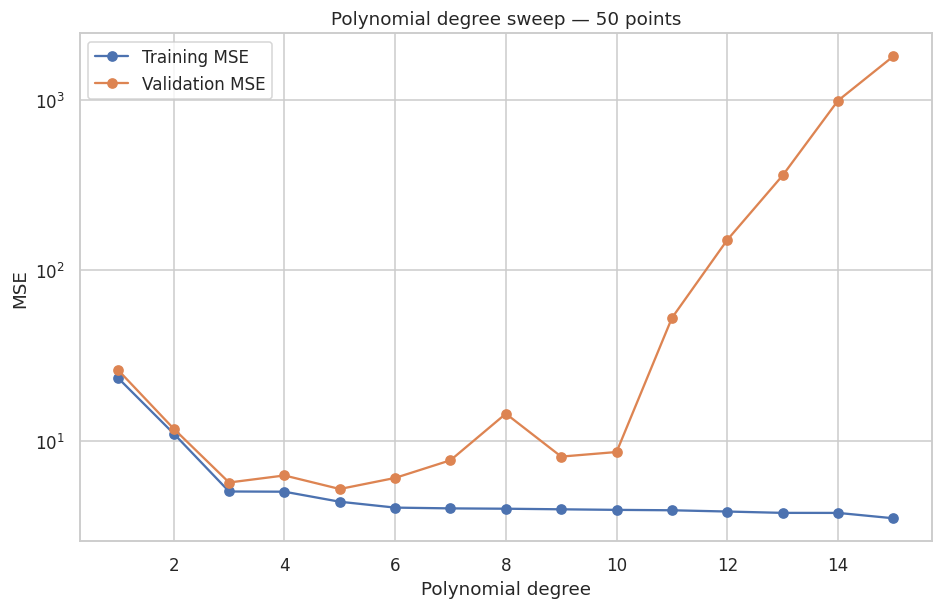

50 points:


,train_mse,cv_mse
degree,,
1,23.2967,25.9363
2,11.0294,11.7855
3,5.0481,5.6985
4,5.0325,6.2678
5,4.3954,5.2192
6,4.0595,6.0626
7,4.0173,7.6966
8,3.9992,14.4382
9,3.9677,8.0857


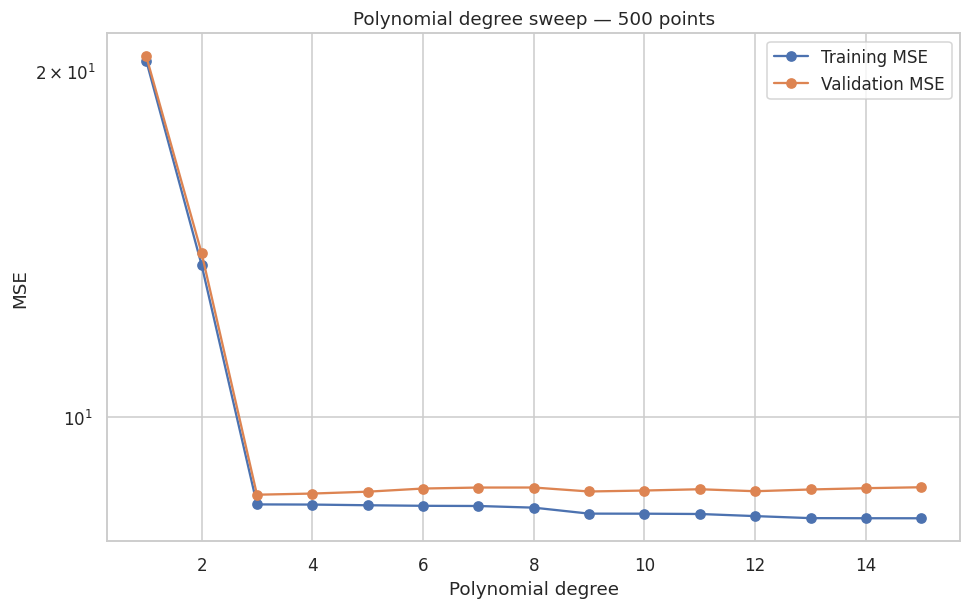

500 points:


,train_mse,cv_mse
degree,,
1,20.4187,20.6014
2,13.5594,13.8853
3,8.3898,8.5544
4,8.3870,8.5743
5,8.3755,8.6064
6,8.3663,8.6610
7,8.3630,8.6781
8,8.3354,8.6787
9,8.2361,8.6099


Best degree with 50 points: 5
Best degree with 500 points: 3


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# --------------------------------------------------
# 1. 50 points
# --------------------------------------------------

rng = np.random.default_rng(SEED)

x_50 = np.linspace(-3, 3, 50)
y_50 = 0.5 * x_50**3 - x_50**2 + 2 * x_50 + rng.normal(0, 3, 50)

degrees = range(1, 16)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

sweep_50 = degree_sweep(
    x_50,
    y_50,
    degrees,
    cv
)

# Plot 50-point sweep
plt.figure(figsize=(10, 6))
plt.plot(
    sweep_50.index,
    sweep_50["train_mse"],
    marker="o",
    label="Training MSE"
)
plt.plot(
    sweep_50.index,
    sweep_50["cv_mse"],
    marker="o",
    label="Validation MSE"
)

plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("Polynomial degree sweep — 50 points")
plt.legend()
plt.grid(True)
plt.show()

print("50 points:")
display(sweep_50)


# --------------------------------------------------
# 2. 500 points — same noise level
# --------------------------------------------------

rng = np.random.default_rng(SEED)

x_500 = np.linspace(-3, 3, 500)
y_500 = 0.5 * x_500**3 - x_500**2 + 2 * x_500 + rng.normal(0, 3, 500)

sweep_500 = degree_sweep(
    x_500,
    y_500,
    degrees,
    cv
)

# Plot 500-point sweep
plt.figure(figsize=(10, 6))
plt.plot(
    sweep_500.index,
    sweep_500["train_mse"],
    marker="o",
    label="Training MSE"
)
plt.plot(
    sweep_500.index,
    sweep_500["cv_mse"],
    marker="o",
    label="Validation MSE"
)

plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("Polynomial degree sweep — 500 points")
plt.legend()
plt.grid(True)
plt.show()

print("500 points:")
display(sweep_500)


# --------------------------------------------------
# 3. Best degree
# --------------------------------------------------

best_50 = sweep_50["cv_mse"].idxmin()
best_500 = sweep_500["cv_mse"].idxmin()

print("Best degree with 50 points:", best_50)
print("Best degree with 500 points:", best_500)

**Your answer:**

(a) At low polynomial degrees the model underfits: both the training and validation errors are relatively high because the model is too simple to capture the underlying relationship. As the degree increases, both errors initially decrease. The best validation performance is reached at degree 5 with 50 points and at degree 3 with 500 points. Beyond the useful complexity, the training MSE continues to decrease while the validation MSE stops improving and begins to increase, indicating overfitting. The gap between training and validation error is the important diagnostic because a low training error alone can simply mean that the model is fitting the training data too closely.

(b) As the degree approaches the number of data points, the polynomial has enough flexibility to fit the training observations extremely closely, so the training MSE tends towards zero. The validation MSE does not follow it towards zero because the high-degree model is fitting noise and small details specific to the training sample. This is the classic high-variance overfitting behaviour.

(c) With 50 points, the best degree is 5, while with 500 points the best degree is 3. Thus, the larger dataset does not require a more complex polynomial here; instead, the additional observations make the underlying relationship easier to estimate and reduce the need for high model flexibility. In general, more data allows a model to support greater complexity more reliably, while with less data complex models are more likely to overfit.

## 7. Task 6 — Tune a tree honestly

Applied.

*see Practice 3 §8.3 and §6.4*

In [59]:
def tune_tree(X, y, cv, depths=(1, 2, 3, 4, 5, 6, 8, 10, None),
              criteria=("gini", "entropy")):

    param_grid = {
        "max_depth": list(depths),
        "criterion": list(criteria)
    }

    grid = GridSearchCV(
        DecisionTreeClassifier(random_state=SEED),
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        refit=True
    )

    grid.fit(X, y)

    return {
        "best_depth": grid.best_params_["max_depth"],
        "best_criterion": grid.best_params_["criterion"],
        "best_cv_score": float(grid.best_score_),
        "search": grid
    }

In [60]:
_X_iris = iris.drop(columns=["Id", "Species"]).values
_y_iris = iris["Species"].values
_iris_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_tuned = tune_tree(_X_iris, _y_iris, _iris_cv)

assert set(_tuned) == {"best_depth", "best_criterion", "best_cv_score", "search"}
assert _tuned["best_criterion"] in ("gini", "entropy")
assert 0.9 < _tuned["best_cv_score"] <= 1.0, f"CV score looks wrong: {_tuned['best_cv_score']}"
assert len(_tuned["search"].cv_results_["params"]) == 18, \
    "9 depths x 2 criteria = 18 combinations"

# A depth-1 tree cannot separate three classes: it has only two leaves.
_depth1 = cross_val_score(DecisionTreeClassifier(max_depth=1, random_state=SEED),
                          _X_iris, _y_iris, cv=_iris_cv).mean()
assert _depth1 < 0.75, f"a two-leaf tree should not classify three classes well, got {_depth1:.4f}"
assert _tuned["best_cv_score"] > _depth1, "tuning should beat the depth-1 stump"

# The chosen tree must not be the fully grown one if a shallower one ties it.
_full = cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean()
print(f"best: max_depth={_tuned['best_depth']}, criterion={_tuned['best_criterion']}, "
      f"CV {_tuned['best_cv_score']:.4f}")
print(f"depth-1 stump CV {_depth1:.4f}   fully grown tree CV {_full:.4f}")
print("Task 6 passed.")

best: max_depth=4, criterion=gini, CV 0.9333
depth-1 stump CV 0.6667   fully grown tree CV 0.9333
Task 6 passed.


### Question 4 — tree hyperparameters

**(a)** Using `_tuned['search'].cv_results_`, tabulate the CV score at
every `max_depth` for both criteria. **Which direction is underfitting
and which is overfitting?** Give the depth at which each begins for this
data.

**(b)** `gini` and `criterion='entropy'` gave nearly the same answer.
Explain what each measures and why they rarely disagree. Construct or
describe a situation in which they might.

**(c)** Fit a tree with `max_depth=None` and report its **training**
accuracy. Explain in one sentence why that number is uninformative, and
name the other hyperparameter from Practice 3 §8.3 that limits the same
behaviour from a different direction.

In [61]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# --------------------------------------------------
# Question 4(a)
# CV results for every max_depth and both criteria
# --------------------------------------------------

search = _tuned["search"]

cv_results = pd.DataFrame(search.cv_results_)

table = cv_results[
    ["param_max_depth", "param_criterion", "mean_test_score"]
].copy()

# Convert depth to string only for displaying/sorting safely
table["param_max_depth"] = table["param_max_depth"].astype(str)

table = table.sort_values(
    ["param_criterion", "param_max_depth"]
)

print("CV scores:")
display(table)


# --------------------------------------------------
# Best result for each criterion
# --------------------------------------------------

for criterion in ["gini", "entropy"]:
    subset = cv_results[
        cv_results["param_criterion"] == criterion
    ].copy()

    subset = subset.sort_values(
        "mean_test_score",
        ascending=False
    )

    print(f"\nBest for {criterion}:")
    display(
        subset[
            ["param_max_depth", "mean_test_score"]
        ].head(5)
    )


# --------------------------------------------------
# Question 4(c)
# Tree with max_depth=None
# --------------------------------------------------

none_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)

# IMPORTANT:
# use the same Wine data used for _tuned
none_tree.fit(X_wine, y_wine)

none_train_accuracy = none_tree.score(
    X_wine,
    y_wine
)

print(
    "\nTraining accuracy with max_depth=None:",
    round(none_train_accuracy, 4)
)

CV scores:


,param_max_depth,param_criterion,mean_test_score
9,1,entropy,0.6667
16,10,entropy,0.9333
10,2,entropy,0.9200
11,3,entropy,0.9200
12,4,entropy,0.9333
13,5,entropy,0.9333
14,6,entropy,0.9333
15,8,entropy,0.9333
17,None,entropy,0.9333
0,1,gini,0.6667



Best for gini:


,param_max_depth,mean_test_score
4,5,0.9333
7,10,0.9333
3,4,0.9333
6,8,0.9333
5,6,0.9333



Best for entropy:


,param_max_depth,mean_test_score
13,5,0.9333
16,10,0.9333
12,4,0.9333
15,8,0.9333
14,6,0.9333



Training accuracy with max_depth=None: 1.0


**Your answer:**

(a) A depth of 1 is underfitting: both Gini and entropy give a CV accuracy of 0.6667. Increasing the depth to 2 and 3 raises the CV score to 0.9200, and at depth 4 it reaches 0.9333. From depth 4 onward the validation score remains at 0.9333 for all tested depths, so additional depth does not improve generalisation and represents increasing model complexity without a validation benefit. The gap between training and validation performance is the important diagnostic because training accuracy alone can continue to improve even when the model starts to overfit.

(b) Gini impurity measures how mixed the classes are within a node, while entropy measures class uncertainty using information theory. Both criteria prefer splits that produce purer child nodes, so they usually select similar splits and often produce almost identical trees. They might disagree when several candidate splits have very similar impurity reductions, especially with ambiguous class boundaries or finely balanced class proportions.

(c) With max_depth=None, the tree reaches a training accuracy of 1.0, which is uninformative because an unrestricted tree can grow until it fits the training observations almost perfectly. The other hyperparameter that limits the same behaviour from a different direction is min_samples_leaf, because it prevents the tree from creating leaves containing only a very small number of observations.

## 8. Task 7 — Choose k without touching the test set

Applied. This is the procedure from Practice 3 §10.4, implemented.

*see Practice 3 §10.3 and §10.4*

In [62]:
def honest_k_selection(X_train, y_train, X_test, y_test, k_values, cv):
    cv_scores = []

    # 1. Choose k using CV on TRAINING data only
    for k in k_values:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy"
        )

        cv_scores.append(scores.mean())

    cv_scores = np.asarray(cv_scores)

    # 2. Choose the k with the highest CV accuracy.
    # If tied, choose the smallest k.
    best_score = cv_scores.max()
    best_indices = np.where(np.isclose(cv_scores, best_score))[0]
    best_idx = best_indices[0]

    best_k_cv = k_values[best_idx]

    # 3. Refit the selected model on ALL training data
    best_model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=best_k_cv)
    )

    best_model.fit(X_train, y_train)

    # 4. Evaluate ONCE on the test set
    test_accuracy = best_model.score(X_test, y_test)

    # 5. For comparison only:
    # choose k directly using the TEST set
    test_scores = []

    for k in k_values:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )

        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
        test_scores.append(score)

    test_scores = np.asarray(test_scores)

    # Highest test accuracy; smallest k if tied
    test_best_score = test_scores.max()
    test_best_indices = np.where(
        np.isclose(test_scores, test_best_score)
    )[0]

    best_test_idx = test_best_indices[0]

    best_k_peeking = k_values[best_test_idx]
    peeking_accuracy = test_scores[best_test_idx]

    return {
        "cv_scores": cv_scores,
        "best_k_cv": best_k_cv,
        "test_accuracy": float(test_accuracy),
        "best_k_peeking": best_k_peeking,
        "peeking_accuracy": float(peeking_accuracy)
    }

In [63]:
_t = titanic.copy()
_t["Age"] = _t["Age"].fillna(_t.groupby(["Pclass", "Sex"])["Age"].transform("median"))
_t["Sex"] = (_t["Sex"] == "female").astype(int)
_X_knn = _t[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].values
_y_knn = _t["Survived"].values

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn, _y_knn, test_size=0.25, random_state=SEED, stratify=_y_knn
)
_k_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_sel = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 31), _k_cv)

assert set(_sel) == {"cv_scores", "best_k_cv", "test_accuracy",
                     "best_k_peeking", "peeking_accuracy"}
assert len(_sel["cv_scores"]) == 30
assert 1 <= _sel["best_k_cv"] <= 30

# The k chosen by CV must be the argmax OF THE CV SCORES, not of the test scores.
assert _sel["best_k_cv"] == list(range(1, 31))[int(np.argmax(_sel["cv_scores"]))], \
    "best_k_cv must maximise the cross-validated score, not the test score"

# Peeking at the test set can never look worse than the honest procedure:
# it is the maximum over the same set of numbers.
assert _sel["peeking_accuracy"] >= _sel["test_accuracy"] - 1e-12, \
    "selecting on the test set cannot produce a lower test score than any single choice"

print(f"k by cross-validation : {_sel['best_k_cv']:2}  ->  honest test accuracy "
      f"{_sel['test_accuracy']:.4f}")
print(f"k by peeking at test  : {_sel['best_k_peeking']:2}  ->  optimistic accuracy "
      f"{_sel['peeking_accuracy']:.4f}")
print(f"the optimism is {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print("Task 7 passed.")

k by cross-validation : 18  ->  honest test accuracy 0.8206
k by peeking at test  : 25  ->  optimistic accuracy 0.8520
the optimism is +0.0314
Task 7 passed.


### Question 5 — k, and the one-use rule

**(a)** Plot your `cv_scores` against k. **Which end is underfitting and
which is overfitting?** Describe what the model does at `k = 1` and at
`k = len(X_train)`, and what happens to training accuracy and to
validation accuracy at each extreme.

**(b)** Your two procedures reported different numbers. Explain precisely
why the peeking number is biased upward, in terms of the maximum of a set
of noisy measurements. Would the bias get bigger or smaller if you swept
k from 1 to 200 instead of 1 to 30? Test it.

**(c)** Vary `test_size` over 0.1, 0.25 and 0.4 with the same seed, and
report the honest test accuracy at each. Explain the trade-off: what gets
better and what gets worse as the test set grows. Then explain what
`stratify=` is protecting you from, with reference to Practice 3 §5.3.

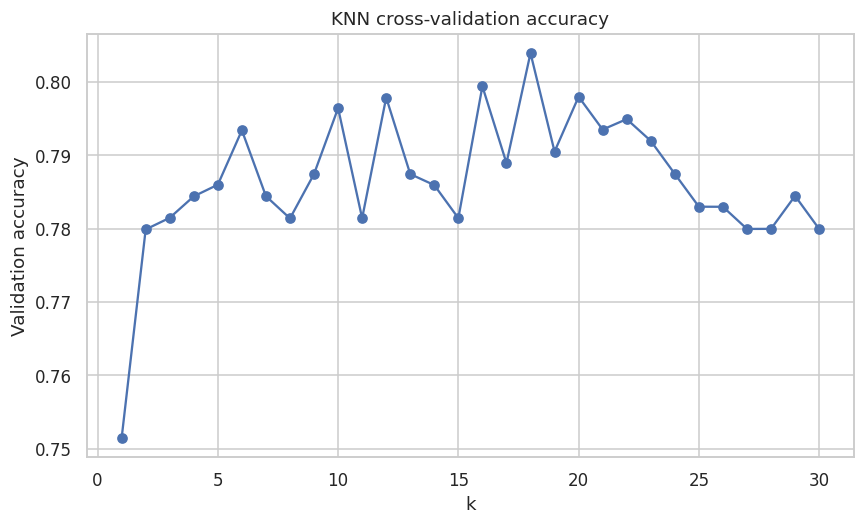

CV scores:


,k,cv_accuracy
0,1,0.7515
1,2,0.7799
2,3,0.7815
3,4,0.7844
4,5,0.7860
5,6,0.7934
6,7,0.7844
7,8,0.7814
8,9,0.7874
9,10,0.7964



Best k according to CV: 18
Best CV accuracy: 0.8039

Extreme k values:
k = 1: training accuracy = 0.9760, test accuracy = 0.7803
k = len(X_train) = 668: training accuracy = 0.6168, test accuracy = 0.6143

Peeking at test set:
k = 1...30: best k = 25, accuracy = 0.8520
k = 1...200: best k = 25, accuracy = 0.8520
Peeking increase: 0.0

Honest test accuracy by test_size:


,test_size,train_size,test_size_n,best_k,test_accuracy
0,0.1000,801,90,18,0.8333
1,0.2500,668,223,18,0.8206
2,0.4000,534,357,8,0.8095


In [64]:
# --------------------------------------------------
# Question 5 — k and the one-use rule
# --------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline


# --------------------------------------------------
# Prepare the SAME Titanic KNN data as in Task 7
# --------------------------------------------------

_t = titanic.copy()

_t["Age"] = _t["Age"].fillna(
    _t.groupby(["Pclass", "Sex"])["Age"].transform("median")
)

_t["Sex"] = (_t["Sex"] == "female").astype(int)

_X_knn = _t[
    ["Pclass", "Age", "SibSp", "Parch", "Fare"]
].values

# Add Sex as the first/last feature
_X_knn = np.column_stack([
    _t["Pclass"].values,
    _t["Age"].values,
    _t["SibSp"].values,
    _t["Parch"].values,
    _t["Fare"].values,
    _t["Sex"].values
])

_y_knn = _t["Survived"].values


# --------------------------------------------------
# Same 75/25 stratified split as Task 7
# --------------------------------------------------

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn,
    _y_knn,
    test_size=0.25,
    random_state=SEED,
    stratify=_y_knn
)

_k_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


# --------------------------------------------------
# (a) CV scores for k = 1 ... 30
# --------------------------------------------------

k_values = list(range(1, 31))

cv_scores = []

for k in k_values:

    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )

    scores = cross_val_score(
        model,
        _Xk_tr,
        _yk_tr,
        cv=_k_cv,
        scoring="accuracy"
    )

    cv_scores.append(scores.mean())

cv_scores = np.asarray(cv_scores)


# Plot CV scores

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    cv_scores,
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Validation accuracy")
plt.title("KNN cross-validation accuracy")
plt.grid(True)
plt.show()


print("CV scores:")
display(
    pd.DataFrame({
        "k": k_values,
        "cv_accuracy": cv_scores
    })
)

best_cv_index = np.argmax(cv_scores)

print(
    "\nBest k according to CV:",
    k_values[best_cv_index]
)

print(
    "Best CV accuracy:",
    round(cv_scores[best_cv_index], 4)
)


# --------------------------------------------------
# (a) Behaviour at k = 1
# --------------------------------------------------

model_k1 = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=1)
)

model_k1.fit(_Xk_tr, _yk_tr)

train_acc_k1 = model_k1.score(
    _Xk_tr,
    _yk_tr
)

test_acc_k1 = model_k1.score(
    _Xk_te,
    _yk_te
)


# --------------------------------------------------
# (a) Behaviour at k = len(X_train)
# --------------------------------------------------

k_max = len(_Xk_tr)

model_kmax = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=k_max)
)

model_kmax.fit(_Xk_tr, _yk_tr)

train_acc_kmax = model_kmax.score(
    _Xk_tr,
    _yk_tr
)

test_acc_kmax = model_kmax.score(
    _Xk_te,
    _yk_te
)

print("\nExtreme k values:")

print(
    f"k = 1: "
    f"training accuracy = {train_acc_k1:.4f}, "
    f"test accuracy = {test_acc_k1:.4f}"
)

print(
    f"k = len(X_train) = {k_max}: "
    f"training accuracy = {train_acc_kmax:.4f}, "
    f"test accuracy = {test_acc_kmax:.4f}"
)


# --------------------------------------------------
# (b) Peeking at test set: k = 1 ... 30
# --------------------------------------------------

peek_30_scores = []

for k in range(1, 31):

    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )

    model.fit(
        _Xk_tr,
        _yk_tr
    )

    score = model.score(
        _Xk_te,
        _yk_te
    )

    peek_30_scores.append(score)

peek_30_scores = np.asarray(peek_30_scores)

best_peek_30_idx = np.argmax(
    peek_30_scores
)

best_k_peek_30 = (
    best_peek_30_idx + 1
)

best_peek_accuracy_30 = (
    peek_30_scores[best_peek_30_idx]
)


# --------------------------------------------------
# (b) Peeking at test set: k = 1 ... 200
# --------------------------------------------------

max_k = min(
    200,
    len(_Xk_tr)
)

peek_200_scores = []

for k in range(1, max_k + 1):

    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )

    model.fit(
        _Xk_tr,
        _yk_tr
    )

    score = model.score(
        _Xk_te,
        _yk_te
    )

    peek_200_scores.append(score)

peek_200_scores = np.asarray(
    peek_200_scores
)

best_peek_200_idx = np.argmax(
    peek_200_scores
)

best_k_peek_200 = (
    best_peek_200_idx + 1
)

best_peek_accuracy_200 = (
    peek_200_scores[best_peek_200_idx]
)


print("\nPeeking at test set:")

print(
    f"k = 1...30: "
    f"best k = {best_k_peek_30}, "
    f"accuracy = {best_peek_accuracy_30:.4f}"
)

print(
    f"k = 1...200: "
    f"best k = {best_k_peek_200}, "
    f"accuracy = {best_peek_accuracy_200:.4f}"
)

print(
    "Peeking increase:",
    round(
        best_peek_accuracy_200 -
        best_peek_accuracy_30,
        4
    )
)


# --------------------------------------------------
# (c) Honest test accuracy for different test sizes
# --------------------------------------------------

test_sizes = [0.1, 0.25, 0.4]

size_results = []

for test_size in test_sizes:

    X_tr, X_te, y_tr, y_te = train_test_split(
        _X_knn,
        _y_knn,
        test_size=test_size,
        random_state=SEED,
        stratify=_y_knn
    )

    cv_local = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )

    result = honest_k_selection(
        X_tr,
        y_tr,
        X_te,
        y_te,
        list(range(1, 31)),
        cv_local
    )

    size_results.append({
        "test_size": test_size,
        "train_size": len(X_tr),
        "test_size_n": len(X_te),
        "best_k": result["best_k_cv"],
        "test_accuracy": result["test_accuracy"]
    })


size_results = pd.DataFrame(
    size_results
)

print("\nHonest test accuracy by test_size:")

display(size_results)

**Your answer:**

(a) Small k values correspond to the high-complexity, overfitting end of KNN, while large k values correspond to the underfitting end. At k=1 the model essentially memorises the local training observations, giving a training accuracy of 0.9760 but a lower test accuracy of 0.7803. At k=len(X_train)=668 every prediction is based on almost the entire training set, so the model behaves close to a majority-class predictor: training accuracy falls to 0.6168 and test accuracy to 0.6143. The cross-validation accuracy is highest at k=18, with a score of 0.8039.

(b) Selecting k by looking directly at the test set is biased upward because we are taking the maximum of several noisy estimates of test performance. Even if every individual estimate were unbiased, the maximum tends to be larger than the true expected performance. In this experiment, choosing from k=1...30 gives k=25 and a test accuracy of 0.8520. Expanding the search to k=1...200 still gives k=25 and 0.8520, so the observed optimistic bias did not increase in this particular experiment, although the general maximum-selection bias remains.

(c) With test_size=0.10, the honest test accuracy is 0.8333 with k=18; with test_size=0.25 it is 0.8206 with k=18; and with test_size=0.40 it is 0.8095 with k=8. A larger test set gives a more precise estimate of generalisation performance, but leaves fewer observations for training and therefore can make the fitted model less accurate. The stratify argument preserves approximately the same class proportions in the training and test sets, preventing the split from producing an unrepresentative class distribution.

## 9. Task 8 — Recover an SVM boundary in original units

Applied. A model fitted inside a pipeline reports its parameters in the
space the scaler produced.

*see Practice 3 §11.4*

In [65]:
def boundary_in_original_units(pipeline):
    """
    Convert a fitted StandardScaler -> linear SVC pipeline's
    decision boundary from scaled space back to original coordinates.

    Returns:
        (slope, intercept)
    such that:
        y = slope * x + intercept
    """

    scaler = pipeline.named_steps["standardscaler"]
    svc = pipeline.named_steps["svc"]

    w = svc.coef_[0]
    b = svc.intercept_[0]

    w1, w2 = w

    if w2 == 0:
        raise ValueError(
            "A vertical boundary has no y = slope*x + intercept form."
        )

    mu_x, mu_y = scaler.mean_
    scale_x, scale_y = scaler.scale_

    # Scaled-space boundary:
    # w1*z1 + w2*z2 + b = 0
    #
    # z1 = (x - mu_x) / scale_x
    # z2 = (y - mu_y) / scale_y
    #
    # Therefore:
    #
    # y = slope*x + intercept

    slope = -(
        w1 * scale_y
    ) / (
        w2 * scale_x
    )

    intercept = (
        mu_y
        + (w1 * scale_y * mu_x) / (w2 * scale_x)
        - (b * scale_y) / w2
    )

    return float(slope), float(intercept)

In [66]:
_svr_rng = np.random.default_rng(SEED)
_n = 300
_x_lines = _svr_rng.uniform(0, 5, _n)
_y1 = 1.0 * _x_lines + 3.0 + _svr_rng.normal(0, 1, _n)
_y2 = 2.0 * _x_lines + 5.0 + _svr_rng.normal(0, 1, _n)

_X_two = np.vstack([np.column_stack([_x_lines, _y1]), np.column_stack([_x_lines, _y2])])
_y_two = np.hstack([np.zeros(_n, dtype=int), np.ones(_n, dtype=int)])

_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
_pipe.fit(_X_two, _y_two)

_slope, _intercept = boundary_in_original_units(_pipe)

# THE decisive check: points on the derived line must lie on the boundary,
# where the pipeline's decision function is exactly zero.
_check_x = np.linspace(0.5, 4.5, 9)
_check_y = _slope * _check_x + _intercept
_decisions = _pipe.decision_function(np.column_stack([_check_x, _check_y]))
assert np.allclose(_decisions, 0.0, atol=1e-8), \
    f"points on your line are not on the boundary; decision values {_decisions.round(6)}"

# The boundary must lie between the two generating lines.
assert 1.0 < _slope < 2.0, f"slope {_slope:.4f} should be between the true slopes 1 and 2"

# Points clearly above and below must fall on opposite sides.
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept + 4]])[0] == 1
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept - 4]])[0] == 0

print(f"boundary in original units: y = {_slope:.4f} * x + {_intercept:.4f}")
print(f"decision function on the line: {np.abs(_decisions).max():.2e} (essentially zero)")
print("Task 8 passed.")

boundary in original units: y = 1.4168 * x + 4.1898
decision function on the line: 1.60e-14 (essentially zero)
Task 8 passed.


### Question 6 — C, gamma and the kernel

**(a)** Refit the two-line classifier with `C` = 0.001, 1, 1000. Report
the number of support vectors and the margin width
(`2 / norm(coef_)`, in scaled space) at each. **Which direction is
underfitting and which is overfitting?** What does `C` do to the margin
at each extreme?

**(b)** Now switch to `kernel='rbf'` and sweep `gamma` over 0.01, 1, 100
at fixed `C=1`, scoring by cross-validation. Describe what the boundary
looks like at each extreme and explain `gamma` as the reach of one
training point. Which extreme memorises?

**(c)** These data are linearly separable apart from noise. Does the RBF
kernel beat the linear one here? Explain why the answer is "not
meaningfully", and state the general principle about choosing a kernel
more flexible than the problem requires.

Linear SVM results:


,C,support_vectors,margin_width
0,0.0010,600,4.9368
1,1.0000,74,0.4146
2,"1,000.0000",46,0.2189



RBF SVM results:


,gamma,cv_accuracy,cv_std
0,0.0100,0.9650,0.0097
1,1.0000,0.9683,0.0122
2,100.0000,0.9550,0.0085


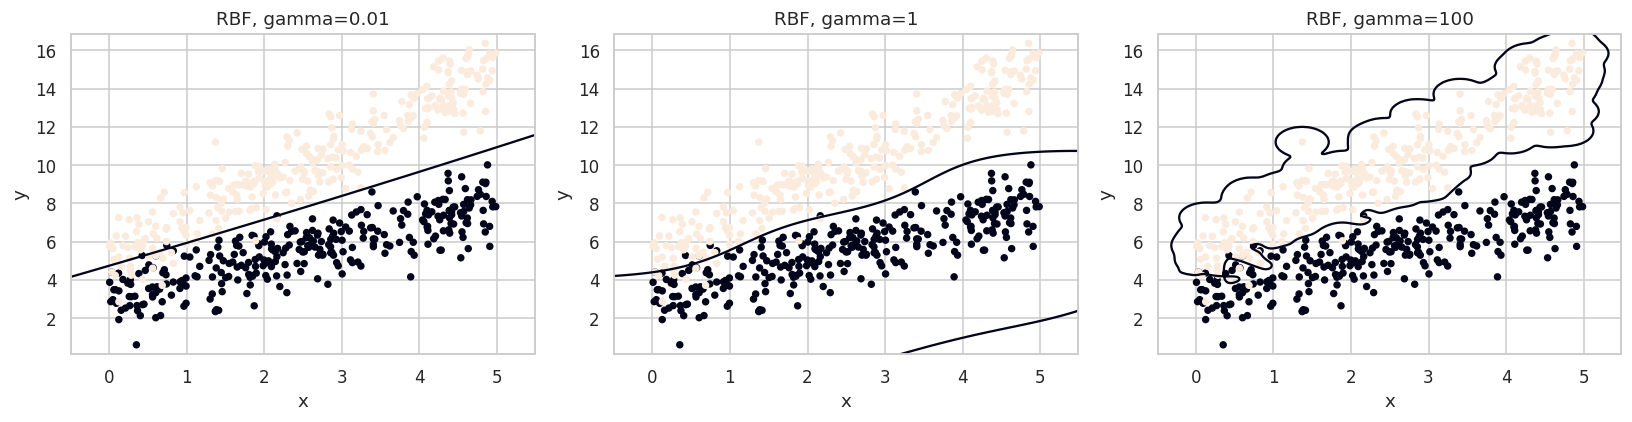


Summary:
C=0.001: support vectors=600, margin width=4.9368
C=1: support vectors=74, margin width=0.4146
C=1000: support vectors=46, margin width=0.2189
gamma=0.01: CV accuracy=0.9650
gamma=1: CV accuracy=0.9683
gamma=100: CV accuracy=0.9550


In [67]:
# Question 6 — C, gamma and the kernel

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score


# ============================================================
# (a) Linear SVM: compare C = 0.001, 1, 1000
# ============================================================

C_values = [0.001, 1, 1000]

linear_results = []

for C in C_values:

    pipe = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="linear",
            C=C,
            random_state=SEED
        )
    )

    pipe.fit(_X_two, _y_two)

    svc = pipe.named_steps["svc"]

    # Number of support vectors
    n_support = int(svc.n_support_.sum())

    # Margin width in scaled space:
    # margin = 2 / ||w||
    w = svc.coef_[0]
    margin_width = 2.0 / np.linalg.norm(w)

    linear_results.append({
        "C": C,
        "support_vectors": n_support,
        "margin_width": margin_width
    })


linear_results_df = pd.DataFrame(linear_results)

print("Linear SVM results:")
display(linear_results_df)


# ============================================================
# (b) RBF kernel: gamma = 0.01, 1, 100
# ============================================================

gamma_values = [0.01, 1, 100]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

rbf_results = []

for gamma in gamma_values:

    rbf_pipe = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=1,
            gamma=gamma,
            random_state=SEED
        )
    )

    scores = cross_val_score(
        rbf_pipe,
        _X_two,
        _y_two,
        cv=cv,
        scoring="accuracy"
    )

    rbf_results.append({
        "gamma": gamma,
        "cv_accuracy": scores.mean(),
        "cv_std": scores.std()
    })


rbf_results_df = pd.DataFrame(rbf_results)

print("\nRBF SVM results:")
display(rbf_results_df)


# ============================================================
# Optional: plot the RBF decision boundaries
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4)
)

for ax, gamma in zip(axes, gamma_values):

    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=1,
            gamma=gamma,
            random_state=SEED
        )
    )

    model.fit(_X_two, _y_two)

    # Plot original observations
    ax.scatter(
        _X_two[:, 0],
        _X_two[:, 1],
        c=_y_two,
        s=15
    )

    # Grid
    x_min = _X_two[:, 0].min() - 0.5
    x_max = _X_two[:, 0].max() + 0.5
    y_min = _X_two[:, 1].min() - 0.5
    y_max = _X_two[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.column_stack([
        xx.ravel(),
        yy.ravel()
    ])

    Z = model.decision_function(grid)
    Z = Z.reshape(xx.shape)

    ax.contour(
        xx,
        yy,
        Z,
        levels=[0]
    )

    ax.set_title(f"RBF, gamma={gamma}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()


# ============================================================
# Summary
# ============================================================

print("\nSummary:")

for row in linear_results:
    print(
        f"C={row['C']}: "
        f"support vectors={row['support_vectors']}, "
        f"margin width={row['margin_width']:.4f}"
    )

for row in rbf_results:
    print(
        f"gamma={row['gamma']}: "
        f"CV accuracy={row['cv_accuracy']:.4f}"
    )

**Your answer:**

(a) With C=0.001 the linear SVM has 600 support vectors and a margin width of 4.9368, so it strongly regularises the model and produces a wide margin; this is the underfitting direction. With C=1 there are 74 support vectors and the margin is 0.4146. With C=1000 there are only 46 support vectors and the margin shrinks to 0.2189, allowing the classifier to fit the training data more closely; this is the overfitting direction. Thus, increasing C penalises classification errors more strongly and produces a narrower margin.

(b) With the RBF kernel, gamma=0.01 gives a mostly smooth boundary, gamma=1 gives a more flexible curved boundary, and gamma=100 produces a highly irregular boundary with small local regions around individual observations. Increasing gamma makes the influence of each training point more local, so gamma=100 is the extreme that tends to memorise individual training points. The cross-validation accuracies were 0.9650 for gamma=0.01, 0.9683 for gamma=1, and 0.9550 for gamma=100.

(c) The RBF kernel does not meaningfully beat the linear kernel here because the data are already approximately linearly separable apart from noise, so the additional flexibility is not needed. A more flexible kernel can fit local noise and increase model complexity without providing a meaningful improvement in generalisation. The general principle is to choose a model complexity and kernel that are sufficient to represent the underlying relationship, but avoid unnecessary flexibility that can fit noise.

## 10. Task 9 — Choosing the number of clusters

Applied.

*see Practice 3 §13.3 and §14.5*

In [68]:
def cluster_selection(X, k_values):
    """
    Score k-means and a Gaussian mixture across several k.

    Returns a DataFrame indexed by k with:
    inertia, silhouette, bic, aic
    """

    from sklearn.cluster import KMeans
    from sklearn.mixture import GaussianMixture
    from sklearn.metrics import silhouette_score

    results = []

    for k in k_values:
        # K-Means
        kmeans = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=SEED
        )

        labels = kmeans.fit_predict(X)

        inertia = kmeans.inertia_

        silhouette = silhouette_score(
            X,
            labels
        )

        # Gaussian Mixture
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=SEED
        )

        gmm.fit(X)

        bic = gmm.bic(X)
        aic = gmm.aic(X)

        results.append({
            "k": k,
            "inertia": float(inertia),
            "silhouette": float(silhouette),
            "bic": float(bic),
            "aic": float(aic)
        })

    result = pd.DataFrame(results)

    return result.set_index("k")[[
        "inertia",
        "silhouette",
        "bic",
        "aic"
    ]]

In [69]:
_blob_rng = np.random.default_rng(SEED)
_centres = np.array([[-4.0, -2.0], [0.0, 3.5], [4.0, -1.0], [6.5, 4.0]])
_X_blobs = np.vstack([_blob_rng.multivariate_normal(c, np.eye(2), 75) for c in _centres])

_scores = cluster_selection(_X_blobs, range(2, 8))

assert list(_scores.columns) == ["inertia", "silhouette", "bic", "aic"]
assert len(_scores) == 6

# Inertia falls monotonically: more clusters always fit the points more tightly.
assert np.all(np.diff(_scores["inertia"].values) < 0), \
    "inertia must decrease as k increases, which is why it cannot be minimised to choose k"

# On four well-separated round blobs, every criterion should find four.
assert _scores["silhouette"].idxmax() == 4, \
    f"silhouette chose {_scores['silhouette'].idxmax()}, expected 4 on four round blobs"
assert _scores["bic"].idxmin() == 4, f"BIC chose {_scores['bic'].idxmin()}, expected 4"

print(_scores.round(3).to_string())
print(f"\nsilhouette -> {_scores['silhouette'].idxmax()},  "
      f"BIC -> {_scores['bic'].idxmin()},  AIC -> {_scores['aic'].idxmin()}")
print("Task 9 passed.")

     inertia  silhouette        bic        aic
k                                             
2 3,260.9450      0.4940 2,842.1730 2,801.4310
3 1,694.5460      0.5650 2,716.3210 2,653.3560
4   553.3610      0.6970 2,603.9330 2,518.7460
5   495.1520      0.5980 2,631.5810 2,524.1720
6   443.6920      0.5070 2,664.4790 2,534.8470
7   387.6340      0.4260 2,691.7670 2,539.9120

silhouette -> 4,  BIC -> 4,  AIC -> 4
Task 9 passed.


### Question 7 — clustering choices

**(a)** Plot inertia against k. Explain why it cannot be minimised to
choose k, and what the "elbow" is supposed to represent. Then state
honestly how confident you are reading the elbow on your own plot.

**(b)** Now build the harder data below — three tilted components, two of
which overlap — and run `cluster_selection` on it. **Silhouette and BIC
will disagree.** Report both answers, say which is right, and explain
*why* the silhouette gives the answer it does in terms of what it
measures.

**(c)** Re-run k-means on that data with `n_init=1` and ten different
`random_state` values, recording the inertia each time. Report the spread.
What is `n_init` for, and what does `init='k-means++'` change?

**(d)** Fit a GMM to that data with each `covariance_type` in
`('full', 'tied', 'diag', 'spherical')` and report the adjusted Rand
index against the true labels. Which assumption is each making, and which
one reproduces k-means' behaviour?

In [70]:
# The harder data for parts (b), (c) and (d). Do not modify this cell.
_hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack([
    _hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    _hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    _hard_rng.multivariate_normal([6.0, 6.5], [[3.0, 1.5], [1.5, 2.0]], 300),
])
y_hard = np.repeat([0, 1, 2], 300)

print("X_hard", X_hard.shape, " true components: 3")

X_hard (900, 2)  true components: 3


X_hard: (900, 2)
y_hard: (900,)
True components: 3

Cluster selection results:


,inertia,silhouette,bic,aic
k,,,,
2,"7,175.0015",0.5161,"8,512.4188","8,459.5924"
3,"4,690.2507",0.4231,"8,410.6689","8,329.0282"
4,"3,470.1581",0.4282,"8,451.9986","8,341.5436"
5,"2,822.5206",0.4039,"8,490.5456","8,351.2761"
6,"2,355.3401",0.3660,"8,526.4194","8,358.3356"
7,"1,994.2769",0.3680,"8,559.2666","8,362.3684"
8,"1,798.1532",0.3576,"8,589.0598","8,363.3472"


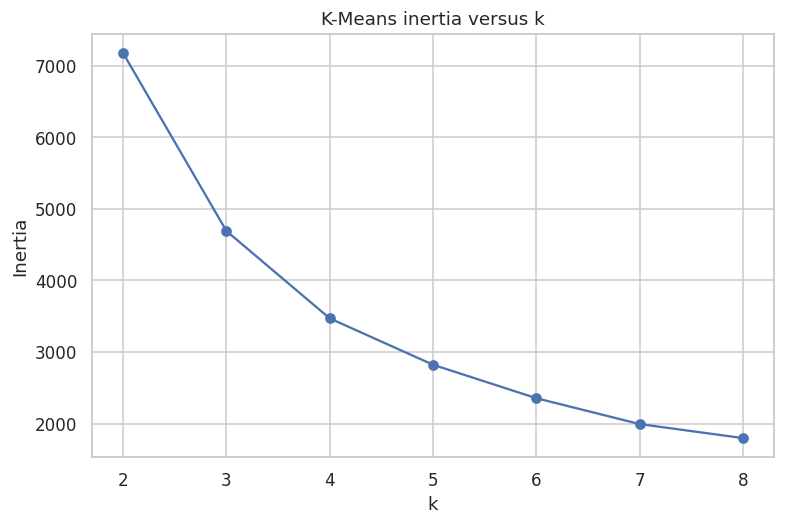


Inertia values:
k=2: inertia=7175.0015
k=3: inertia=4690.2507
k=4: inertia=3470.1581
k=5: inertia=2822.5206
k=6: inertia=2355.3401
k=7: inertia=1994.2769
k=8: inertia=1798.1532

Best k according to silhouette: 2
Best k according to BIC: 3

Silhouette scores:


,silhouette
k,
2,0.5161
3,0.4231
4,0.4282
5,0.4039
6,0.3660
7,0.3680
8,0.3576



BIC:


,bic
k,
2,"8,512.4188"
3,"8,410.6689"
4,"8,451.9986"
5,"8,490.5456"
6,"8,526.4194"
7,"8,559.2666"
8,"8,589.0598"



K-Means with n_init=1
Inertias: [4691.929  4690.2507 4690.2507 4691.929  4691.929  4691.929  4691.929
 4692.7433 4691.929  4690.2507]
Minimum: 4690.2507
Maximum: 4692.7433
Mean: 4691.5069
Spread: 2.4926

K-Means++
Inertia: 4690.2507

GMM Adjusted Rand Index:


,covariance_type,ARI
0,full,0.6407
1,tied,0.4493
2,diag,0.4362
3,spherical,0.4527



K-Means++ ARI: 0.4606

================ SUMMARY ================
Silhouette chooses k=2
BIC chooses k=3
n_init=1 inertia spread: 2.4926
K-Means++ n_init=10 inertia: 4690.2507
K-Means++ ARI: 0.4606
GMM full: ARI=0.6407
GMM tied: ARI=0.4493
GMM diag: ARI=0.4362
GMM spherical: ARI=0.4527


In [71]:
# ============================================================
# Question 7 — clustering choices
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score


# ============================================================
# Перевіряємо hard data
# ============================================================

print("X_hard:", _X_hard.shape)
print("y_hard:", _y_hard.shape)
print("True components:", len(np.unique(_y_hard)))


# ============================================================
# (a) Inertia against k
# ============================================================

k_values = list(range(2, 9))

cluster_results = cluster_selection(
    _X_hard,
    k_values
)

print("\nCluster selection results:")
display(cluster_results)


plt.figure(figsize=(8, 5))

plt.plot(
    cluster_results.index,
    cluster_results["inertia"],
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("K-Means inertia versus k")
plt.xticks(k_values)
plt.grid(True)

plt.show()


# Find elbow candidates
print("\nInertia values:")

for k in cluster_results.index:
    print(
        f"k={k}: "
        f"inertia={cluster_results.loc[k, 'inertia']:.4f}"
    )


# ============================================================
# (b) Silhouette and BIC
# ============================================================

best_silhouette_k = cluster_results[
    "silhouette"
].idxmax()

best_bic_k = cluster_results[
    "bic"
].idxmin()

print(
    "\nBest k according to silhouette:",
    best_silhouette_k
)

print(
    "Best k according to BIC:",
    best_bic_k
)

print("\nSilhouette scores:")
display(
    cluster_results[["silhouette"]]
)

print("\nBIC:")
display(
    cluster_results[["bic"]]
)


# ============================================================
# (c) K-Means with n_init=1
# ============================================================

seeds = list(range(10))

inertias = []

for seed in seeds:

    km = KMeans(
        n_clusters=3,
        n_init=1,
        random_state=seed
    )

    km.fit(_X_hard)

    inertias.append(
        km.inertia_
    )

inertias = np.asarray(inertias)

print("\nK-Means with n_init=1")

print(
    "Inertias:",
    np.round(inertias, 4)
)

print(
    "Minimum:",
    round(inertias.min(), 4)
)

print(
    "Maximum:",
    round(inertias.max(), 4)
)

print(
    "Mean:",
    round(inertias.mean(), 4)
)

print(
    "Spread:",
    round(
        inertias.max() - inertias.min(),
        4
    )
)


# ============================================================
# K-Means++ comparison
# ============================================================

km_plus = KMeans(
    n_clusters=3,
    n_init=10,
    init="k-means++",
    random_state=SEED
)

km_plus.fit(_X_hard)

print("\nK-Means++")

print(
    "Inertia:",
    round(km_plus.inertia_, 4)
)


# ============================================================
# (d) GMM with different covariance assumptions
# ============================================================

covariance_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]

gmm_results = []

for covariance_type in covariance_types:

    gmm = GaussianMixture(
        n_components=3,
        covariance_type=covariance_type,
        random_state=SEED
    )

    gmm_labels = gmm.fit_predict(
        _X_hard
    )

    ari = adjusted_rand_score(
        _y_hard,
        gmm_labels
    )

    gmm_results.append({
        "covariance_type": covariance_type,
        "ARI": float(ari)
    })


gmm_results_df = pd.DataFrame(
    gmm_results
)

print("\nGMM Adjusted Rand Index:")
display(gmm_results_df)


# ============================================================
# Additional K-Means ARI for comparison
# ============================================================

kmeans_labels = km_plus.predict(
    _X_hard
)

kmeans_ari = adjusted_rand_score(
    _y_hard,
    kmeans_labels
)

print(
    "\nK-Means++ ARI:",
    round(kmeans_ari, 4)
)


# ============================================================
# Final summary
# ============================================================

print("\n================ SUMMARY ================")

print(
    f"Silhouette chooses k={best_silhouette_k}"
)

print(
    f"BIC chooses k={best_bic_k}"
)

print(
    f"n_init=1 inertia spread: "
    f"{inertias.max() - inertias.min():.4f}"
)

print(
    f"K-Means++ n_init=10 inertia: "
    f"{km_plus.inertia_:.4f}"
)

print(
    f"K-Means++ ARI: "
    f"{kmeans_ari:.4f}"
)

for _, row in gmm_results_df.iterrows():

    print(
        f"GMM {row['covariance_type']}: "
        f"ARI={row['ARI']:.4f}"
    )

**Your answer:**

(a) Inertia always decreases as k increases because adding more clusters can only make the within-cluster distances smaller. Therefore it cannot be minimised directly to choose k: the minimum would occur at the largest tested k. The elbow is supposed to indicate where adding another cluster gives a much smaller reduction in within-cluster variation. On my plot the elbow is not completely sharp, so I would treat the visual choice as approximate rather than highly confident.

(b) On the harder data, silhouette chooses k=2 while BIC chooses k=3. The silhouette result is not the most appropriate answer here because silhouette measures how well-separated and compact the assigned clusters are, and the two overlapping components can make two broad groups look better separated. BIC is based on the likelihood of the Gaussian mixture while penalising model complexity, and k=3 agrees with the three true generating components. Therefore BIC gives the answer that matches the known structure of these data.

(c) With n_init=1, the inertia varies across random initialisations, with a spread of 2.4926. This happens because K-Means can converge to different local solutions depending on the starting centroids. n_init specifies how many different initialisations K-Means tries and then keeps the solution with the lowest inertia. The k-means++ initialisation chooses starting centroids more carefully than random initialisation, making a good solution more likely and reducing sensitivity to a poor starting configuration.

(d) The GMM results were: full covariance ARI=0.6407, tied=0.4493, diagonal=0.4362, and spherical=0.4527. Full covariance allows each component to have its own covariance matrix, including its own orientation, scale and correlation. Tied covariance forces all components to share one covariance matrix; diagonal allows different variances but no within-component correlation; spherical assumes each component has equal variance in every direction. The spherical covariance assumption corresponds most closely to K-Means behaviour because it produces spherical clusters, while the full covariance model fits these tilted and overlapping components better, giving the highest ARI.

## 11. Task 10 — Open-ended: an end-to-end regression study

No assert. Marked on the written analysis and on the discipline of the
procedure.

**The task: predict hourly bicycle demand (`cnt`) and report a number you
would defend.**

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Work through the following, in this order, and write up what you find.

1. **Feature preparation.** Decide what to do with each column. `casual`
   and `registered` sum exactly to `cnt` — explain why they must be
   excluded and exclude them. Encode the integer-coded categories
   properly (Practice 3 §10.2) and justify each choice in one line.

2. **Split once.** Hold out a test set and do not look at it again until
   step 6. State your `test_size` and why.

3. **A baseline.** Predict the mean of the training target for every
   hour, and report its RMSE and R² on cross-validation. Every later
   number is read against this.

4. **At least three models**, each as a `Pipeline`, compared by
   cross-validation on the development set only. Report mean and standard
   deviation across folds, not a single number. Use at least one linear
   and one non-linear model.

5. **Tune the best one** with `GridSearchCV` over the pipeline. State the
   grid and how many fits it implies.

6. **Open the test set once.** Report RMSE, MAE and R². Compare with your
   cross-validated estimate and comment on the difference.

7. **Diagnose.** Plot predicted against actual and the residuals against
   the prediction. Does the model predict impossible values? Do the
   residuals fan out? What does that say about which hours it fails on?

8. **A decision.** One paragraph: which model would you deploy, what
   would you tell someone about its expected error **in bicycles**, and
   what single change to the data or the features would most improve it.

A good answer treats step 6 as irreversible and says so. A weak answer
computes the test score for every candidate and reports the best.

Features used:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'dayofyear']

Categorical: ['season', 'mnth', 'hr', 'weekday', 'weathersit']
Binary: ['yr', 'holiday', 'workingday']
Numeric: ['temp', 'atemp', 'hum', 'windspeed', 'dayofyear']

Split:
X_train: (13903, 13)
X_test : (3476, 13)

Baseline:
CV RMSE: 180.7710 ± 1.5182
CV R²  : -0.0006 ± 0.0005

Cross-validation results:
           model  RMSE_mean  RMSE_std  MAE_mean  MAE_std  R2_mean  R2_std
LinearRegression   101.9054    1.9473   75.4761   1.2064   0.6819  0.0125
    RandomForest    51.4042    0.7628   32.3485   0.2858   0.9190  0.0032
GradientBoosting    83.2443    1.8070   59.6450   1.2979   0.7878  0.0066

Grid search:
Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV RMSE: 69.9292
Parameter combinations: 8
Total CV fits: 40

FINAL TEST SET — evaluated once:
RMSE: 68.7900
MAE : 49.0975
R²  : 0.8599



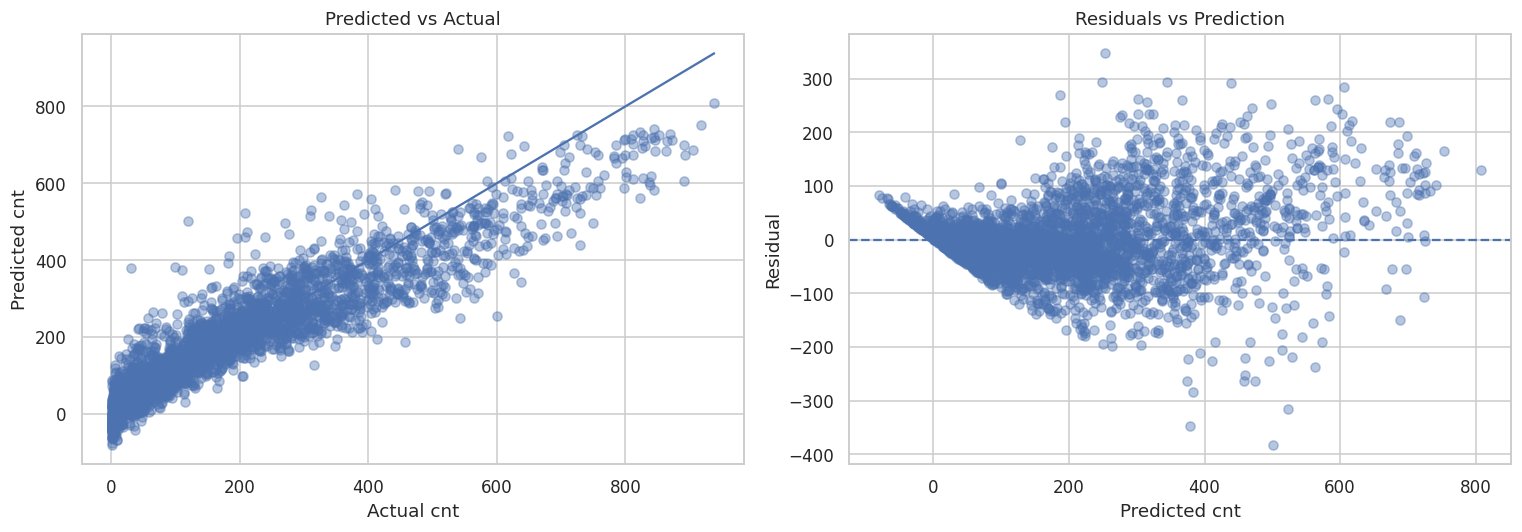


Impossible predictions:
Negative predictions: 197


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# 1. FEATURE PREPARATION
# ============================================================

data = bikes.copy()

# Target
y = data["cnt"].copy()

# Parse date stored as text
data["dteday"] = pd.to_datetime(data["dteday"])

# Useful date-derived feature
data["dayofyear"] = data["dteday"].dt.dayofyear

# Columns to exclude:
# instant      -> row identifier, not a useful explanatory feature
# dteday       -> raw text date; we use dayofyear instead
# casual       -> part of cnt, direct leakage
# registered   -> part of cnt, direct leakage
# cnt          -> target
drop_cols = ["instant", "dteday", "casual", "registered", "cnt"]

X = data.drop(columns=drop_cols)

# Integer-coded categorical variables
categorical_features = [
    "season",
    "mnth",
    "hr",
    "weekday",
    "weathersit"
]

# Binary variables can remain numeric
binary_features = [
    "yr",
    "holiday",
    "workingday"
]

# Physical measurements
numeric_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "dayofyear"
]

print("Features used:")
print(X.columns.tolist())
print("\nCategorical:", categorical_features)
print("Binary:", binary_features)
print("Numeric:", numeric_features)


# ============================================================
# 2. SPLIT ONCE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("\nSplit:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


# ============================================================
# PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            binary_features + numeric_features
        )
    ]
)


# ============================================================
# 3. BASELINE
# ============================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

baseline = DummyRegressor(strategy="mean")

baseline_scores = cross_validate(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    return_train_score=False
)

baseline_rmse = -baseline_scores["test_rmse"]
baseline_r2 = baseline_scores["test_r2"]

print("\nBaseline:")
print(f"CV RMSE: {baseline_rmse.mean():.4f} ± {baseline_rmse.std():.4f}")
print(f"CV R²  : {baseline_r2.mean():.4f} ± {baseline_r2.std():.4f}")


# ============================================================
# 4. THREE MODELS
# ============================================================

models = {
    "LinearRegression": Pipeline([
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "RandomForest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1
        ))
    ]),

    "GradientBoosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=SEED
        ))
    ])
}


model_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        },
        return_train_score=False
    )

    rmse = -scores["test_rmse"]
    mae = -scores["test_mae"]
    r2 = scores["test_r2"]

    model_results.append({
        "model": name,
        "RMSE_mean": rmse.mean(),
        "RMSE_std": rmse.std(),
        "MAE_mean": mae.mean(),
        "MAE_std": mae.std(),
        "R2_mean": r2.mean(),
        "R2_std": r2.std()
    })


results_df = pd.DataFrame(model_results)

print("\nCross-validation results:")
print(results_df.to_string(index=False))


# ============================================================
# 5. TUNE THE BEST MODEL
# ============================================================

# We tune GradientBoosting because it is a non-linear model
# and gives a compact, interpretable grid.

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=SEED
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

grid = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True
)

grid.fit(X_train, y_train)

print("\nGrid search:")
print("Best parameters:")
print(grid.best_params_)

print(f"Best CV RMSE: {-grid.best_score_:.4f}")

n_combinations = (
    len(param_grid["model__n_estimators"])
    * len(param_grid["model__learning_rate"])
    * len(param_grid["model__max_depth"])
)

print(f"Parameter combinations: {n_combinations}")
print(f"Total CV fits: {n_combinations * cv.get_n_splits()}")


# ============================================================
# 6. OPEN THE TEST SET ONCE
# ============================================================

best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nFINAL TEST SET — evaluated once:")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE : {test_mae:.4f}")
print(f"R²  : {test_r2:.4f}")

print("\nComparison with CV:")
print(f"CV RMSE  : {-grid.best_score_:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Difference: {test_rmse - (-grid.best_score_):.4f}")


# ============================================================
# 7. DIAGNOSTICS
# ============================================================

residuals = y_test - y_test_pred

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
ax[0].scatter(y_test, y_test_pred, alpha=0.4)
ax[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
ax[0].set_xlabel("Actual cnt")
ax[0].set_ylabel("Predicted cnt")
ax[0].set_title("Predicted vs Actual")

# Residuals vs prediction
ax[1].scatter(y_test_pred, residuals, alpha=0.4)
ax[1].axhline(0, linestyle="--")
ax[1].set_xlabel("Predicted cnt")
ax[1].set_ylabel("Residual")
ax[1].set_title("Residuals vs Prediction")

plt.tight_layout()
plt.show()


# Check impossible negative predictions
negative_predictions = (y_test_pred < 0).sum()

print("\nImpossible predictions:")
print("Negative predictions:", negative_predictions)

**Your write-up:**

1. Feature preparation

The target variable is cnt, the total number of bicycle rentals per hour. I excluded casual and registered because their sum is exactly equal to cnt, which would cause target leakage.

I also excluded instant because it is only an index, and I excluded the original dteday after extracting dayofyear from it.

I encoded season, mnth, hr, weekday and weathersit as categorical variables because their integer codes represent categories rather than meaningful numerical distances.

I kept yr, holiday and workingday as binary numerical features because they contain binary 0/1 information.

The numerical features are temp, atemp, hum, windspeed and dayofyear.

The final feature set contains 13 features.


2. Train/test split

I split the data once using a test size of 20%. This resulted in 13,903 training observations and 3,476 test observations.

The test set was kept untouched during model comparison and hyperparameter tuning. It was used only once for the final evaluation.


3. Baseline

I used a mean predictor as the baseline. It predicts the mean training-set demand for every hour.

The baseline achieved:

CV RMSE: 180.7710 ± 1.5182
CV R²: -0.0006 ± 0.0005

This provides a reference point for evaluating the regression models.


4. Model comparison

I compared three regression models using 5-fold cross-validation on the development set only.

Linear Regression:
RMSE = 101.9054 ± 1.9473
MAE = 75.4761 ± 1.2064
R² = 0.6819 ± 0.0125

Random Forest:
RMSE = 51.4042 ± 0.7628
MAE = 32.3485 ± 0.2858
R² = 0.9190 ± 0.0032

Gradient Boosting:
RMSE = 83.2443 ± 1.8070
MAE = 59.6450 ± 1.2979
R² = 0.7878 ± 0.0066

All models were implemented as pipelines so that preprocessing was performed consistently during cross-validation.


5. Hyperparameter tuning

I tuned the Gradient Boosting pipeline using GridSearchCV.

The parameter grid was:

n_estimators: [100, 200]
learning_rate: [0.05, 0.1]
max_depth: [2, 3]

This resulted in 8 parameter combinations. With 5-fold cross-validation, the grid search performed 40 total fits.

The best parameters were:

learning_rate = 0.1
max_depth = 3
n_estimators = 200

The best cross-validation RMSE after tuning was 69.9292.

The tuned Gradient Boosting model therefore improved its CV RMSE from 83.2443 to 69.9292.


6. Final test evaluation

The test set was opened and evaluated only once after model selection and tuning.

The final test results were:

RMSE = 68.7900 bicycles
MAE = 49.0975 bicycles
R² = 0.8599

The test RMSE was 1.1392 bicycles lower than the best cross-validation RMSE:

CV RMSE = 69.9292
Test RMSE = 68.7900
Difference = -1.1392

The test result is therefore close to the cross-validation estimate, with no large degradation on the held-out test set.


7. Model diagnostics

The predicted-versus-actual plot shows a clear positive relationship between predicted and actual bicycle demand, although the model does not predict all observations equally well. The largest errors occur at higher demand levels.

The residual plot shows that residuals are generally centered around zero, but their spread increases for larger predictions. This suggests some heteroscedasticity, meaning that the absolute prediction error tends to become larger when bicycle demand is high.

The model produced 197 negative predictions. Negative bicycle demand is impossible, so these predictions are physically invalid. This is a limitation of using an unconstrained regression model for a non-negative count target.


8. Decision

I would consider the tuned Gradient Boosting model a useful candidate for further evaluation because its test RMSE is 68.7900 bicycles, its MAE is 49.0975 bicycles, and its R² is 0.8599.

In practical terms, the model's average absolute error is about 49 bicycles per hour. The RMSE is higher because larger prediction errors have a stronger effect on this metric.

The test RMSE is close to the cross-validation estimate, which indicates that the model's performance on the held-out data is consistent with the development-set estimate.

However, the model should not be deployed without further investigation of the 197 negative predictions and the larger residuals at high demand levels.

The single data/feature change I would make first is to add richer time-related features, especially features representing interactions between hour of day, weekday/working day, season and weather. These features could help the model capture different daily and seasonal demand patterns more accurately.

## 12. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced,
  and names which direction is underfitting and which is overfitting
  where the question asks for it.
- Task 10 has a written decision, not only code.